#### Arducam notebook setup to analyze contours across the full 12nov2025_phys recording. This was run on Osiris with large video files saved there. The kernel used there is called "video"

In [2]:
from pathlib import Path
import sys
import os

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return p

ROOT = find_repo_root(Path.cwd())
LUNAR_SCRIPTS = Path('/home/local/ADS/oakley/labdata/users/Oakley/GitHub/lunar/scripts')
if str(LUNAR_SCRIPTS) not in sys.path:
    sys.path.append(str(LUNAR_SCRIPTS))

from find_contours import find_contours_from_videos

print('Repo root:', ROOT)
print('Using contour scripts from:', LUNAR_SCRIPTS)
print('find_contours_from_videos import: OK')

Repo root: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry
Using contour scripts from: /home/local/ADS/oakley/labdata/users/Oakley/GitHub/lunar/scripts
find_contours_from_videos import: OK


In [3]:
# ---- Pipeline Configuration ----
exp_id = '12nov2025_phys'

video_root = ROOT / 'video' / 'arducamvids'
video_dir = video_root / exp_id
results_dir = ROOT / 'data' / 'processed'
results_dir.mkdir(parents=True, exist_ok=True)

# Support both layouts:
# 1) video/arducamvids/11nov2025_phys/11nov2025_phys_part*.mp4
# 2) video/arducamvids/11nov2025_phys_part*.mp4
video_patterns = [
    str(video_dir / f'{exp_id}_part*.mp4'),
    str(video_root / f'{exp_id}_part*.mp4'),
]
video_pattern = video_patterns[0]
output_file = str(results_dir / f'contours_{exp_id}.tab')

print('Video root:', video_root)
print('Preferred nested dir:', video_dir)
print('Output file:', output_file)

Video root: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry/video/arducamvids
Preferred nested dir: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry/video/arducamvids/12nov2025_phys
Output file: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry/data/processed/contours_12nov2025_phys.tab


In [4]:
import glob
import re

def part_key(path_str):
    name = Path(path_str).name
    m = re.search(r'_part(\d+)\.mp4$', name)
    return int(m.group(1)) if m else float('inf')

videos = []
for pat in video_patterns:
    found = sorted(glob.glob(pat), key=part_key)
    if found:
        video_pattern = pat
        videos = found
        break

print('Using video pattern:', video_pattern)
print(f'Found {len(videos)} videos')
for v in videos[:10]:
    print(' -', Path(v).name)
if len(videos) > 10:
    print('...')
print('First 12 part numbers:', [part_key(v) for v in videos[:12]])

assert len(videos) > 0, 'No videos found. Checked both nested and flat arducamvids layouts.'

Using video pattern: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry/video/arducamvids/12nov2025_phys_part*.mp4
Found 26 videos
 - 12nov2025_phys_part1.mp4
 - 12nov2025_phys_part2.mp4
 - 12nov2025_phys_part3.mp4
 - 12nov2025_phys_part4.mp4
 - 12nov2025_phys_part5.mp4
 - 12nov2025_phys_part6.mp4
 - 12nov2025_phys_part7.mp4
 - 12nov2025_phys_part8.mp4
 - 12nov2025_phys_part9.mp4
 - 12nov2025_phys_part10.mp4
...
First 12 part numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


### Find the frame/time where lights turn off 

In [4]:
import subprocess
import cv2
import re
import pandas as pd

probe_video = videos[1] if len(videos) > 1 else videos[0]
print('Probe video:', probe_video)
print('File exists:', os.path.exists(probe_video))

cmd = (
    f'ffmpeg -hide_banner -nostats -i "{probe_video}" '
    '-vf "blackdetect=d=0.5:pix_th=0.10" -an -f null - 2>&1 | grep "black_start" | tail -1'
)
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
line = result.stdout.strip()
print('blackdetect line:', line)

match = re.search(r'black_start:(\d+\.\d+)\s+black_end:(\d+\.\d+)\s+black_duration:(\d+\.?\d*)', line)
if match:
    black_start = float(match.group(1))
    black_end = float(match.group(2))
    black_duration = float(match.group(3))
else:
    black_start = black_end = black_duration = None

cap = cv2.VideoCapture(probe_video)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
total_length = frame_count / fps if fps else None

def sec_to_mmss(seconds):
    if seconds is None:
        return ''
    m, s = divmod(int(seconds), 60)
    return f'{m:02d}:{s:02d}'

def sec_to_frame(seconds, fps):
    if seconds is None or not fps:
        return ''
    return int(round(seconds * fps))

table = [
    {'event': 'total_length', 'frame': frame_count, 'time (mm:ss)': sec_to_mmss(total_length)},
    {'event': 'blackstart', 'frame': sec_to_frame(black_start, fps), 'time (mm:ss)': sec_to_mmss(black_start)},
    {'event': 'blackend', 'frame': sec_to_frame(black_end, fps), 'time (mm:ss)': sec_to_mmss(black_end)},
    {'event': 'blackduration', 'frame': sec_to_frame(black_duration, fps), 'time (mm:ss)': sec_to_mmss(black_duration)},
]
darkness = pd.DataFrame(table)
darkness

Probe video: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry/video/arducamvids/12nov2025_phys_part2.mp4
File exists: True
blackdetect line: [blackdetect @ 0x7f35a0003b80] black_start:0 black_end:1930.7 black_duration:1930.7


,event,frame,time (mm:ss)
0,total_length,19308,32:10
1,blackstart,,
2,blackend,,
3,blackduration,,


In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Quick blue-blob scan + preview frames ----
LOWER_BLUE = np.array([90, 60, 40], dtype=np.uint8)
UPPER_BLUE = np.array([140, 255, 255], dtype=np.uint8)
MIN_BLOB_AREA = 20

# Keep this at 300 for fast visual checks; set to 1 for full analysis.
DETECTION_STRIDE = 1
MAX_FRAMES_TO_SHOW = 0
MAX_VIDEOS_TO_SCAN = 27

# Default behavior: reuse existing CSV and skip expensive full rescan.
FORCE_RESCAN = False

BLOBS_CSV = results_dir / f'blobs_{exp_id}.csv'

def detect_blue_blobs(frame_bgr, lower_blue, upper_blue, min_blob_area=25):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_blob_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        cx = x + w // 2
        cy = y + h // 2
        blobs.append({
            'bbox': (x, y, w, h),
            'center': (cx, cy),
            'area': float(area),
        })
    return mask, blobs

if BLOBS_CSV.exists() and not FORCE_RESCAN:
    print(f'Using existing blob detections (set FORCE_RESCAN=True to rerun): {BLOBS_CSV}')
    blob_df = pd.read_csv(BLOBS_CSV)

    if len(blob_df) > 0 and 'detection_id' not in blob_df.columns:
        blob_df = blob_df.sort_values(['video_name', 'frame', 'x', 'y']).reset_index(drop=True)
        blob_df.insert(0, 'detection_id', np.arange(1, len(blob_df) + 1))

    if len(blob_df) == 0:
        print('Existing blob CSV is empty.')
    else:
        print(f'Loaded {len(blob_df)} blob detections across {blob_df.video_name.nunique()} videos')
        if 'video_name' in blob_df.columns:
            print('\nDetections per video:')
            print(blob_df.groupby('video_name').size().to_string())
else:
    preview_images = []
    preview_labels = []
    preview_masks = []
    blob_detections = []

    # Skip first video because recording started before analysis window.
    videos_to_scan = videos[1:1 + MAX_VIDEOS_TO_SCAN]
    print('Skipping first video:', Path(videos[0]).name if len(videos) > 0 else 'N/A')
    print(f'Scanning {len(videos_to_scan)} video(s) for blue blobs...')
    print(f'DETECTION_STRIDE = {DETECTION_STRIDE} (set to 1 for full analysis)')

    if len(videos_to_scan) == 0:
        print('No videos left to scan after skipping the first video.')

    for video_path in videos_to_scan:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print('Could not open:', video_path)
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        sampled = range(0, total_frames, DETECTION_STRIDE)
        print(f'- {Path(video_path).name}: {total_frames} frames, sampling every {DETECTION_STRIDE}')

        for fidx in sampled:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
            ok, frame = cap.read()
            if not ok or frame is None:
                continue

            mask, blobs = detect_blue_blobs(
                frame,
                lower_blue=LOWER_BLUE,
                upper_blue=UPPER_BLUE,
                min_blob_area=MIN_BLOB_AREA,
            )

            if len(blobs) == 0:
                continue

            for b in blobs:
                x, y, w, h = b['bbox']
                cx, cy = b['center']
                blob_detections.append({
                    'video_name': Path(video_path).name,
                    'video_path': str(video_path),
                    'frame': int(fidx),
                    't_sec': (float(fidx) / fps) if fps else np.nan,
                    'x': int(cx),
                    'y': int(cy),
                    'area': float(b['area']),
                    'bbox_x': int(x),
                    'bbox_y': int(y),
                    'bbox_w': int(w),
                    'bbox_h': int(h),
                })

            if len(preview_images) < MAX_FRAMES_TO_SHOW:
                overlay = frame.copy()
                for b in blobs:
                    x, y, w, h = b['bbox']
                    cx, cy = b['center']
                    cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)
                    cv2.circle(overlay, (cx, cy), 3, (255, 255, 255), -1)

                overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
                mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)

                preview_images.append(overlay_rgb)
                preview_masks.append(mask_rgb)
                preview_labels.append(f"{Path(video_path).name}\nframe {fidx} | blobs={len(blobs)}")

        cap.release()

    blob_df = pd.DataFrame(blob_detections)
    if len(blob_df) == 0:
        print('No blue blobs found with current thresholds.')
        print('Try widening HSV range or lowering MIN_BLOB_AREA.')
    else:
        blob_df = blob_df.sort_values(['video_name', 'frame', 'x', 'y']).reset_index(drop=True)
        blob_df.insert(0, 'detection_id', np.arange(1, len(blob_df) + 1))
        blob_df.to_csv(BLOBS_CSV, index=False)

        print(f'Found {len(blob_df)} blob detections across {blob_df.video_name.nunique()} videos')
        print(f'Saved blob detections: {BLOBS_CSV}')
        print('\nDetections per video:')
        print(blob_df.groupby('video_name').size().to_string())

        if len(preview_images) > 0:
            n = len(preview_images)
            cols = 2
            rows = n
            plt.figure(figsize=(15, 5 * rows))
            for i, (img, mask, lbl) in enumerate(zip(preview_images, preview_masks, preview_labels), start=1):
                ax = plt.subplot(rows, cols, 2 * i - 1)
                ax.imshow(img)
                ax.set_title(f"{lbl}\n(annotated)", fontsize=9)
                ax.axis('off')

                ax = plt.subplot(rows, cols, 2 * i)
                ax.imshow(mask, cmap='gray')
                ax.set_title(f"{lbl}\n(detected blue mask)", fontsize=9)
                ax.axis('off')

            plt.tight_layout()
            plt.show()

print('Current thresholds:')
print('LOWER_BLUE =', LOWER_BLUE.tolist())
print('UPPER_BLUE =', UPPER_BLUE.tolist())
print('MIN_BLOB_AREA =', MIN_BLOB_AREA)

if 'blob_df' in globals() and len(blob_df) > 0:
    blob_df.head(10)

Skipping first video: 12nov2025_phys_part1.mp4
Scanning 25 video(s) for blue blobs...
DETECTION_STRIDE = 1 (set to 1 for full analysis)
- 12nov2025_phys_part2.mp4: 19308 frames, sampling every 1
- 12nov2025_phys_part3.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part4.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part5.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part6.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part7.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part8.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part9.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part10.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part11.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part12.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part13.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part14.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part15.mp4: 18000 frames, sampling every 1
- 12nov2025_phys_part16.mp4: 180

[mov,mp4,m4a,3gp,3g2,mj2 @ 0x556152d98000] moov atom not found


Could not open: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry/video/arducamvids/12nov2025_phys_part26.mp4
Found 6265 blob detections across 24 videos
Saved blob detections: /home/likewise-open/ADS/oakley/labdata/users/Oakley/GitHub/signal_respirometry/data/processed/blobs_12nov2025_phys.csv

Detections per video:
video_name
12nov2025_phys_part10.mp4      46
12nov2025_phys_part11.mp4      54
12nov2025_phys_part12.mp4      37
12nov2025_phys_part13.mp4      21
12nov2025_phys_part14.mp4      54
12nov2025_phys_part15.mp4     197
12nov2025_phys_part16.mp4      60
12nov2025_phys_part17.mp4      51
12nov2025_phys_part18.mp4      75
12nov2025_phys_part19.mp4      83
12nov2025_phys_part2.mp4      821
12nov2025_phys_part20.mp4      32
12nov2025_phys_part21.mp4      29
12nov2025_phys_part22.mp4     104
12nov2025_phys_part23.mp4     179
12nov2025_phys_part24.mp4     166
12nov2025_phys_part25.mp4    1305
12nov2025_phys_part3.mp4      768
12nov2025_phys_part4.mp4     

### Blob y-position over cumulative frame/time (part2 to partN)

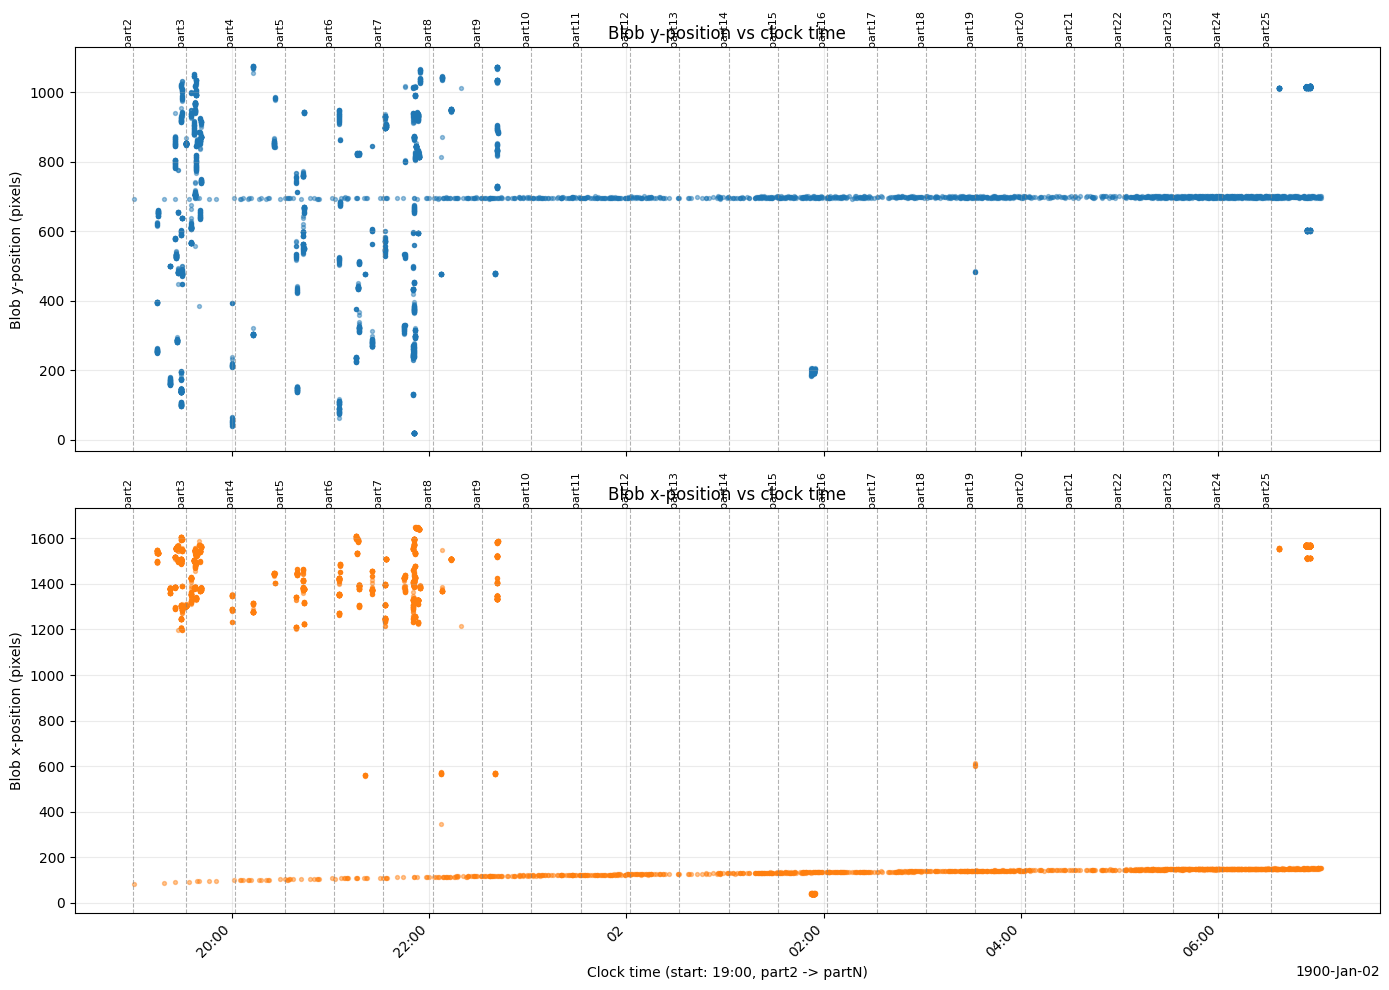

Videos included (ordered):
               video_name  part_num  total_frames  fps
 12nov2025_phys_part2.mp4         2         19308 10.0
 12nov2025_phys_part3.mp4         3         18000 10.0
 12nov2025_phys_part4.mp4         4         18000 10.0
 12nov2025_phys_part5.mp4         5         18000 10.0
 12nov2025_phys_part6.mp4         6         18000 10.0
 12nov2025_phys_part7.mp4         7         18000 10.0
 12nov2025_phys_part8.mp4         8         18000 10.0
 12nov2025_phys_part9.mp4         9         18000 10.0
12nov2025_phys_part10.mp4        10         18000 10.0
12nov2025_phys_part11.mp4        11         18000 10.0
12nov2025_phys_part12.mp4        12         18000 10.0
12nov2025_phys_part13.mp4        13         18000 10.0
12nov2025_phys_part14.mp4        14         18000 10.0
12nov2025_phys_part15.mp4        15         18000 10.0
12nov2025_phys_part16.mp4        16         18000 10.0
12nov2025_phys_part17.mp4        17         18000 10.0
12nov2025_phys_part18.mp4        18   

In [10]:
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from pathlib import Path

# ---- Recording start time (wall clock) ----
RECORDING_START_TIME = "19:00"  # 7:00 PM; change to e.g. "18:45" if needed

# Load detections from memory (preferred) or CSV.
if 'blob_df' in globals() and isinstance(blob_df, pd.DataFrame) and len(blob_df) > 0:
    plot_df = blob_df.copy()
else:
    csv_path = BLOBS_CSV if 'BLOBS_CSV' in globals() else (results_dir / f'blobs_{exp_id}.csv')
    if not csv_path.exists():
        raise FileNotFoundError(f'Blob CSV not found: {csv_path}. Run the blob detection cell first.')
    plot_df = pd.read_csv(csv_path)

required_cols = {'video_name', 'video_path', 'frame', 'x', 'y'}
missing_cols = required_cols.difference(set(plot_df.columns))
if missing_cols:
    raise ValueError(f'Missing required columns in blob detections: {sorted(missing_cols)}')

# Parse part number to enforce part2 -> partN order.
def extract_part_num(video_name: str):
    m = re.search(r'_part(\d+)\.mp4$', str(video_name))
    return int(m.group(1)) if m else np.inf

video_info = (
    plot_df[['video_name', 'video_path']]
    .drop_duplicates()
    .assign(part_num=lambda d: d['video_name'].map(extract_part_num))
    .sort_values(['part_num', 'video_name'])
    .reset_index(drop=True)
)

# Keep only named part videos and (by default) start at part2.
video_info = video_info[video_info['part_num'].notna() & np.isfinite(video_info['part_num'])]
video_info = video_info[video_info['part_num'] >= 2].reset_index(drop=True)
if len(video_info) == 0:
    raise ValueError('No part2..partN videos found in blob detections.')

# Gather per-video frame counts and fps for cumulative time axis.
meta_rows = []
for _, row in video_info.iterrows():
    vp = str(row['video_path'])
    cap = cv2.VideoCapture(vp)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if fps is None or fps <= 0:
        fps = np.nan

    meta_rows.append({
        'video_name': row['video_name'],
        'video_path': vp,
        'part_num': int(row['part_num']),
        'fps': float(fps) if not np.isnan(fps) else np.nan,
        'total_frames': total_frames,
        'duration_sec': (total_frames / fps) if fps and not np.isnan(fps) else np.nan,
    })

video_meta = pd.DataFrame(meta_rows)
video_meta['time_offset_sec'] = video_meta['duration_sec'].fillna(0).shift(fill_value=0).cumsum()

plot_df = plot_df.merge(
    video_meta[['video_name', 'video_path', 'fps', 'time_offset_sec']],
    on=['video_name', 'video_path'],
    how='inner'
)

if len(plot_df) == 0:
    raise ValueError('No detections remained after filtering to part2..partN.')

plot_df['local_t_sec'] = np.where(
    (plot_df['fps'] > 0) & (~plot_df['fps'].isna()),
    plot_df['frame'] / plot_df['fps'],
    np.nan,
)
plot_df['global_t_sec'] = plot_df['time_offset_sec'] + plot_df['local_t_sec'].fillna(0)

# Convert to wall clock time.
t0 = datetime.strptime(RECORDING_START_TIME, "%H:%M")
plot_df['clock_time'] = plot_df['global_t_sec'].apply(lambda s: t0 + timedelta(seconds=s))

# Two stacked plots: y-position and x-position vs clock time.
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].scatter(plot_df['clock_time'], plot_df['y'], s=8, alpha=0.45)
axes[0].set_ylabel('Blob y-position (pixels)')
axes[0].set_title('Blob y-position vs clock time')
axes[0].grid(True, alpha=0.25)

axes[1].scatter(plot_df['clock_time'], plot_df['x'], s=8, alpha=0.45, color='tab:orange')
axes[1].set_xlabel(f'Clock time (start: {RECORDING_START_TIME}, part2 -> partN)')
axes[1].set_ylabel('Blob x-position (pixels)')
axes[1].set_title('Blob x-position vs clock time')
axes[1].grid(True, alpha=0.25)

# Auto-pick tick spacing based on the actual time span; format as HH:MM.
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator, formats=['%Y', '%b', '%d', '%H:%M', '%H:%M', '%S.%f'])
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate(rotation=45)

# Add video boundary markers and labels on both panels.
for _, vr in video_meta.iterrows():
    t_boundary = t0 + timedelta(seconds=float(vr['time_offset_sec']))
    label = f"part{int(vr['part_num'])}"

    axes[0].axvline(x=t_boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[1].axvline(x=t_boundary, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

    y_top0 = axes[0].get_ylim()[1]
    y_top1 = axes[1].get_ylim()[1]
    axes[0].text(t_boundary, y_top0, label, rotation=90, va='bottom', ha='right', fontsize=8)
    axes[1].text(t_boundary, y_top1, label, rotation=90, va='bottom', ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Videos included (ordered):')
print(video_meta[['video_name', 'part_num', 'total_frames', 'fps']].to_string(index=False))
print(f'\nDetections plotted: {len(plot_df)}')
print(f'Recording start time: {RECORDING_START_TIME}')


### Hotspot diagnostic (x-y space, not time-separated)

Use this to verify whether detections cluster in a specific x/y window.

Hotspot diagnostic summary
Source CSV: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/blobs_12nov2025_phys.csv
Total detections: 6265
Detections in hotspot window: 1113
Window: x in [1520, 1600], y in [960, 1040]

Counts by part:
part_num
9       35
25    1078


,video_name,frame,t_sec,x,y
2043,12nov2025_phys_part25.mp4,2700,270.0,1560,1010
2044,12nov2025_phys_part25.mp4,2701,270.1,1556,1011
2045,12nov2025_phys_part25.mp4,2702,270.2,1556,1011
2046,12nov2025_phys_part25.mp4,2703,270.3,1556,1012
2047,12nov2025_phys_part25.mp4,2704,270.4,1556,1012
2048,12nov2025_phys_part25.mp4,2705,270.5,1556,1012
2049,12nov2025_phys_part25.mp4,2706,270.6,1556,1012
2050,12nov2025_phys_part25.mp4,2707,270.7,1555,1012
2051,12nov2025_phys_part25.mp4,2708,270.8,1556,1012
2052,12nov2025_phys_part25.mp4,2709,270.9,1555,1012


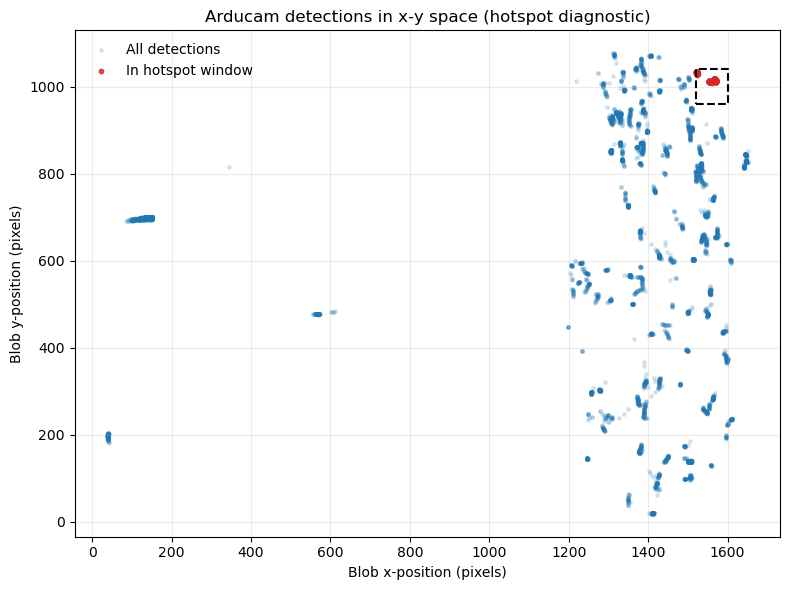

In [2]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve processed CSV path even if setup cells were not run in this kernel.
if 'BLOBS_CSV' in globals():
    csv_path = Path(BLOBS_CSV)
else:
    root = Path.cwd().resolve()
    if not (root / 'pyproject.toml').exists() and (root.parent / 'pyproject.toml').exists():
        root = root.parent
    exp_name = globals().get('exp_id', '12nov2025_phys')
    csv_path = root / 'data' / 'processed' / f'blobs_{exp_name}.csv'

# Load detections from memory (preferred) or CSV.
if 'blob_df' in globals() and isinstance(blob_df, pd.DataFrame) and len(blob_df) > 0:
    hs_df = blob_df.copy()
else:
    if not csv_path.exists():
        raise FileNotFoundError(f'Blob CSV not found: {csv_path}. Run the blob detection cell first.')
    hs_df = pd.read_csv(csv_path)

# Window suspected as nuisance hotspot.
x_min, x_max = 1520.0, 1600.0
y_min, y_max = 960.0, 1040.0

hotspot_mask = hs_df['x'].between(x_min, x_max) & hs_df['y'].between(y_min, y_max)
hotspot_df = hs_df.loc[hotspot_mask].copy()

def extract_part_num(video_name: str):
    m = re.search(r'_part(\d+)\.mp4$', str(video_name))
    return int(m.group(1)) if m else np.nan

hotspot_df['part_num'] = hotspot_df['video_name'].map(extract_part_num)

print('Hotspot diagnostic summary')
print('=' * 72)
print(f'Source CSV: {csv_path}')
print(f'Total detections: {len(hs_df)}')
print(f'Detections in hotspot window: {len(hotspot_df)}')
print(f'Window: x in [{x_min:.0f}, {x_max:.0f}], y in [{y_min:.0f}, {y_max:.0f}]')
if len(hotspot_df) > 0:
    print('\nCounts by part:')
    print(hotspot_df.groupby('part_num').size().to_string())
    display(hotspot_df[['video_name', 'frame', 't_sec', 'x', 'y']].head(10))

# Plot x-y directly so persistent x/y clusters are obvious.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(hs_df['x'], hs_df['y'], s=6, alpha=0.15, label='All detections', color='tab:blue')
if len(hotspot_df) > 0:
    ax.scatter(hotspot_df['x'], hotspot_df['y'], s=10, alpha=0.8, label='In hotspot window', color='tab:red')

# Draw hotspot box.
ax.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Blob x-position (pixels)')
ax.set_ylabel('Blob y-position (pixels)')
ax.set_title('Arducam detections in x-y space (hotspot diagnostic)')
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

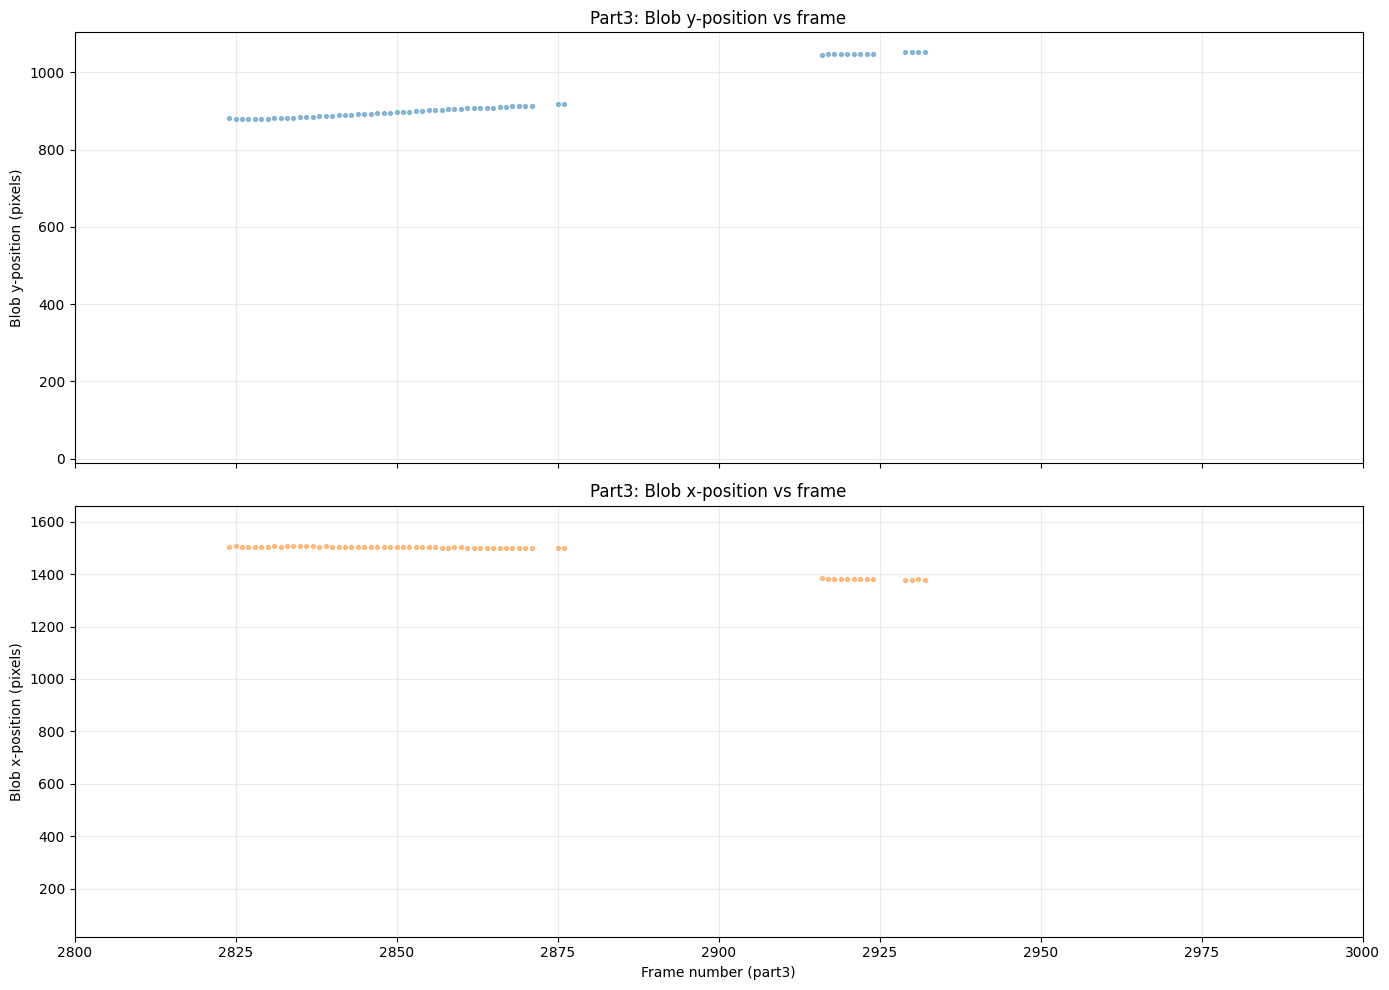

Part plotted: part3
Video file(s):
 - 12nov2025_phys_part3.mp4
Detections plotted: 768
Frame range in data: 0 to 17524
X-axis window applied: XMIN=2800, XMAX=3000


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot detections from one video part only, with frame index on x-axis.
TARGET_PART = 3
XMIN = 2800  # e.g., 1000 or None
XMAX = 3000  # e.g., 5000 or None
YMIN = None  # y-axis lower limit for both panels, e.g. 100
YMAX = None  # y-axis upper limit for both panels, e.g. 800

# Load detections from memory (preferred) or CSV.
if 'blob_df' in globals() and isinstance(blob_df, pd.DataFrame) and len(blob_df) > 0:
    single_video_df = blob_df.copy()
else:
    csv_path = BLOBS_CSV if 'BLOBS_CSV' in globals() else (results_dir / f'blobs_{exp_id}.csv')
    if not csv_path.exists():
        raise FileNotFoundError(f'Blob CSV not found: {csv_path}. Run the blob detection cell first.')
    single_video_df = pd.read_csv(csv_path)

required_cols = {'video_name', 'frame', 'x', 'y'}
missing_cols = required_cols.difference(set(single_video_df.columns))
if missing_cols:
    raise ValueError(f'Missing required columns in blob detections: {sorted(missing_cols)}')

def extract_part_num(video_name: str):
    m = re.search(r'_part(\d+)\.mp4$', str(video_name))
    return int(m.group(1)) if m else np.nan

single_video_df['part_num'] = single_video_df['video_name'].map(extract_part_num)
part_df = single_video_df[single_video_df['part_num'] == TARGET_PART].copy()

if len(part_df) == 0:
    raise ValueError(f'No detections found for part{TARGET_PART}.')

part_df = part_df.sort_values(['video_name', 'frame', 'x', 'y']).reset_index(drop=True)

part_videos = part_df['video_name'].drop_duplicates().tolist()
if len(part_videos) > 1:
    print('Warning: detections for this part appear in multiple files:')
    for vn in part_videos:
        print(' -', vn)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].scatter(part_df['frame'], part_df['y'], s=8, alpha=0.45)
axes[0].set_ylabel('Blob y-position (pixels)')
axes[0].set_title(f'Part{TARGET_PART}: Blob y-position vs frame')
axes[0].grid(True, alpha=0.25)

axes[1].scatter(part_df['frame'], part_df['x'], s=8, alpha=0.45, color='tab:orange')
axes[1].set_xlabel(f'Frame number (part{TARGET_PART})')
axes[1].set_ylabel('Blob x-position (pixels)')
axes[1].set_title(f'Part{TARGET_PART}: Blob x-position vs frame')
axes[1].grid(True, alpha=0.25)

if XMIN is not None or XMAX is not None:
    axes[0].set_xlim(left=XMIN, right=XMAX)
    axes[1].set_xlim(left=XMIN, right=XMAX)

if YMIN is not None or YMAX is not None:
    axes[0].set_ylim(bottom=YMIN, top=YMAX)
    axes[1].set_ylim(bottom=YMIN, top=YMAX)

plt.tight_layout()
plt.show()

print(f'Part plotted: part{TARGET_PART}')
print('Video file(s):')
for vn in part_videos:
    print(' -', vn)
print(f'Detections plotted: {len(part_df)}')
print(f'Frame range in data: {int(part_df["frame"].min())} to {int(part_df["frame"].max())}')
print(f'X-axis window applied: XMIN={XMIN}, XMAX={XMAX}')
print(f'Y-axis window applied: YMIN={YMIN}, YMAX={YMAX}')


### Extract video clips around detected blobs (±5 seconds) - to visualize detections

In [1]:
import cv2
from pathlib import Path

# Configuration
CLIP_BEFORE_SEC = 5
CLIP_AFTER_SEC = 5
ONE_CLIP_PER_FRAME = True
CLIPS_OUTPUT_DIR = results_dir / 'blob_clips'
CLIPS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def get_video_fps_and_total_frames(video_path):
    """Get FPS and total frame count from a video."""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return fps, total_frames

def extract_video_clip(video_path, start_frame, end_frame, output_path):
    """Extract a clip from start_frame to end_frame and save it."""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, start_frame))

    frame_count = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        current_frame = int(cap.get(cv2.CAP_PROP_POS_FRAMES)) - 1
        if current_frame > end_frame:
            break

        if current_frame >= start_frame:
            out.write(frame)
            frame_count += 1

    cap.release()
    out.release()
    return frame_count

if 'blob_df' not in globals() or len(blob_df) == 0:
    raise RuntimeError('blob_df is empty. Run the blob detection cell first.')

clip_events = blob_df[['video_name', 'video_path', 'frame', 't_sec']].copy()
if ONE_CLIP_PER_FRAME:
    clip_events = clip_events.drop_duplicates(subset=['video_name', 'frame']).reset_index(drop=True)

print(f'Preparing clips for {len(clip_events)} event(s)')
print(f'Output directory: {CLIPS_OUTPUT_DIR}')

video_meta = {}
for vp in clip_events['video_path'].unique():
    fps, total_frames = get_video_fps_and_total_frames(vp)
    video_meta[vp] = {'fps': fps, 'total_frames': total_frames}

clip_count = 0
for _, evt in clip_events.iterrows():
    video_name = evt['video_name']
    video_path = evt['video_path']
    detected_frame = int(evt['frame'])

    fps = video_meta[video_path]['fps']
    total_frames = video_meta[video_path]['total_frames']

    frames_before = int(CLIP_BEFORE_SEC * fps)
    frames_after = int(CLIP_AFTER_SEC * fps)

    start_frame = max(0, detected_frame - frames_before)
    end_frame = min(total_frames - 1, detected_frame + frames_after)

    video_stem = Path(video_name).stem
    clip_filename = f'blob_clip_{clip_count:04d}_{video_stem}_frame{detected_frame}.mp4'
    clip_path = CLIPS_OUTPUT_DIR / clip_filename

    print(f'Extracting clip {clip_count}: {video_name} frames {start_frame}-{end_frame}...', end=' ')
    try:
        frames_written = extract_video_clip(video_path, start_frame, end_frame, clip_path)
        print(f'OK ({frames_written} frames)')
        clip_count += 1
    except Exception as e:
        print(f'ERROR: {e}')

print(f'\nExtracted {clip_count} video clips to: {CLIPS_OUTPUT_DIR}')
print('Use a video player to review the clips.')

NameError: name 'results_dir' is not defined